# TOV solver

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

In [3]:
G = 6.67e-8
c_2 = (3e10)**2

In [101]:
def P(r, p,m,  e):


    
    return ((-1*G*m*e)/(c_2*(r**2)))*(1+ (p/e))*(1+((4*np.pi*(r**3)*p)/(m*c_2)))*((1-((2*G*m)/(r*c_2)))**-1)

def M(r ,e):

    return (4*np.pi*(r**2)*e)/(c_2)

In [5]:
# read in EOS
eos = pd.read_csv('eos.csv')

In [102]:
e_arr = np.array(eos['energy_densityc2'])*c_2 
p_arr = np.array(eos['pressurec2'])*c_2

In [43]:
final_mass = []
final_radius = []
pressures = np.concatenate([np.arange(1,10, 0.1)*1e34, np.arange(1,10,0.1)*1e35, np.arange(1,10,0.1)*1e36])# start with initial conditions

for pressure in pressures: 
    # run for each pressure 
    r = [1e-10]   # cm
    h = 100
    m = [1e-10]
    p = [pressure]
    while((p[-1]>0)):# run each star until pressure is 0 
        
    
        ind = np.argmin(np.abs(p_arr- p[-1]))
        #print(ind)
        e = e_arr[ind]
        #print(P(r, p[-1], m[-1], e ))
        p.append(p[-1] +h* P(r[-1], p[-1], m[-1], e ))
        m.append(m[-1] +h* M(r[-1], e))
        r.append( r[-1] +h)  # increase radius step 
    final_mass.append(m[-1])
    final_radius.append(r[-1])
    

In [44]:
mass_msun = np.array(final_mass)/ 1.989e33
radius_km = np.array(final_radius)/ 100000

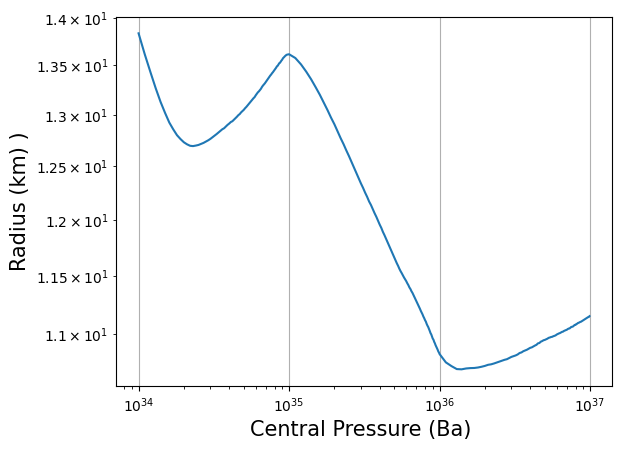

In [98]:
fig, ax = plt.subplots(1)
ax.loglog(pressures , radius_km)
ax.set_xlabel('Central Pressure (Ba) ', fontsize = 15)
ax.set_ylabel('Radius (km) )', fontsize = 15)
ax.grid()
plt.savefig('presurevsradius.png', bbox_inches = 'tight')

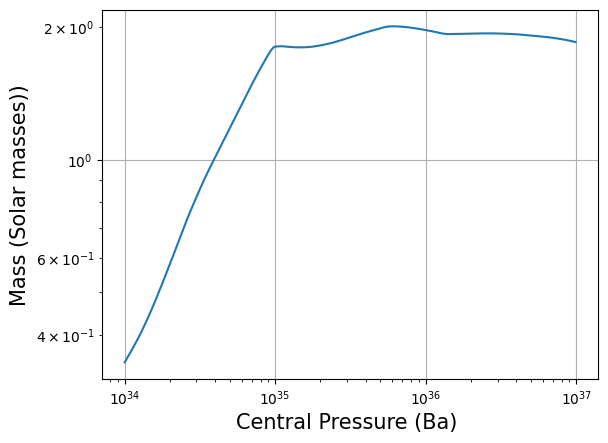

In [99]:
fig, ax = plt.subplots(1)
ax.loglog(pressures , mass_msun)
ax.set_xlabel('Central Pressure (Ba) ', fontsize = 15)
ax.set_ylabel('Mass (Solar masses))', fontsize = 15)
plt.savefig('presurevsmass.png', bbox_inches = 'tight')
ax.grid()

In [96]:
sch = (np.array(final_radius) *c_2)/ (2*G)

In [50]:
len(radius_km)

270

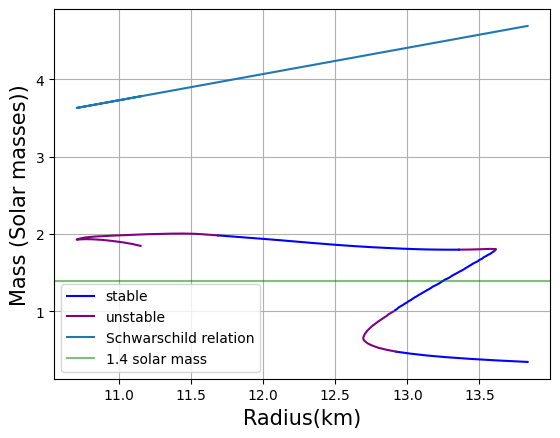

In [100]:
fig, ax = plt.subplots(1)
ax.plot(radius_km[:7], mass_msun[:7], label = 'stable', c = 'b')
ax.plot(radius_km[6:30], mass_msun[6:30], label = 'unstable', c ='purple')
ax.plot(radius_km[30:85], mass_msun[30:85], c = 'b')
ax.plot(radius_km[85:95], mass_msun[85:95], c = 'purple')
ax.plot(radius_km[94:130], mass_msun[94:130], c = 'blue')

ax.plot(radius_km[129:], mass_msun[129:], c = 'purple')


ax.plot(radius_km, sch/1.989e33 , label = 'Schwarschild relation')
ax.grid()
ax.set_xlabel('Radius(km)', fontsize = 15)
ax.set_ylabel('Mass (Solar masses))', fontsize = 15)
ax.axhline(1.4 , c = 'green', label = '1.4 solar mass', alpha = 0.5)
ax.legend()
plt.savefig('tovplot.png', bbox_inches = 'tight')